# Dual form Blatter Pattyn

In [1]:
import irksome
import firedrake
from icepack2.model import hybrid, mass_balance
from firedrake import dx, max_value
import matplotlib.pyplot as plt
import numpy as np
import icepack
from icepack.constants import (
    ice_density as ρ_I,
    water_density as ρ_W,
    weertman_sliding_law ,
    gravity as g,
    glen_flow_law,
)

Lx = 50e3
nx = 48 * 2
mesh1d = firedrake.IntervalMesh(nx, Lx)
mesh = firedrake.ExtrudedMesh(mesh1d, layers=1)

## Define helpers
To compare the primal and dual, we will need to boil the results down to something 1d.

In [2]:
def extract_surface(q_in):
    mesh_x = q_in.ufl_domain()._base_mesh
    shape = q_in.ufl_shape
    if len(shape) == 0:
        VLin = firedrake.FunctionSpace(q_in.ufl_domain(), "CG", 2, vfamily="CG", vdegree=1)
        q_targ = firedrake.Function(VLin).interpolate(q_in)
        element_xz = q_targ.ufl_element()
        if hasattr(element_xz, "factor_elements"):
            element_x = element_xz.factor_elements[0]
        else:
            element_x = element_xz.sub_elements[0]
    else:
        VLin = firedrake.VectorFunctionSpace(q_in.ufl_domain(), "CG", 2, dim=shape[0], vfamily="CG", vdegree=1)
        q_targ = firedrake.Function(VLin).interpolate(q_in)
        element_xz = q_targ.ufl_element()
        if hasattr(element_xz, "factor_elements"):
            element_hor = element_xz.factor_elements[0]
        else:
            element_hor = element_xz.sub_elements[0]
        if hasattr(element_hor, "factor_elements"):
            element_xy = element_hor.factor_elements[0]
        else:
            element_xy = element_hor.sub_elements[0]
        element_x = firedrake.VectorElement(element_xy, dim=shape[0])

    Q_x = firedrake.FunctionSpace(mesh_x, element_x)
    q_x = firedrake.Function(Q_x)
    if len(shape) > 0:
        q_x.dat.data[:] = q_targ.dat.data[1::2, :]
    else:
        q_x.dat.data[:] = q_targ.dat.data[1::2]
    return q_x


def extract_bed(q_in):
    mesh_x = q_in.ufl_domain()._base_mesh
    shape = q_in.ufl_shape
    if len(shape) == 0:
        VLin = firedrake.FunctionSpace(q_in.ufl_domain(), "CG", 2, vfamily="CG", vdegree=1)
        q_targ = firedrake.Function(VLin).interpolate(q_in)
        element_xz = q_targ.ufl_element()
        if hasattr(element_xz, "factor_elements"):
            element_x = element_xz.factor_elements[0]
        else:
            element_x = element_xz.sub_elements[0]
    else:
        VLin = firedrake.VectorFunctionSpace(q_in.ufl_domain(), "CG", 2, dim=shape[0], vfamily="CG", vdegree=1)
        q_targ = firedrake.Function(VLin).interpolate(q_in)
        element_xz = q_targ.ufl_element()
        if hasattr(element_xz, "factor_elements"):
            element_xy = element_xz.factor_elements[0].sub_elements[0]
        elif hasattr(element_xz.sub_elements[0], "factor_elements"):
            element_xy = element_xz.sub_elements[0].factor_elements[0]
        else:
            element_xy = element_xz.sub_elements[0].sub_elements[0]
        element_x = firedrake.VectorElement(element_xy, dim=shape[0])

    Q_x = firedrake.FunctionSpace(mesh_x, element_x)
    q_x = firedrake.Function(Q_x)
    if len(shape) > 0:
        q_x.dat.data[:] = q_targ.dat.data[::2, :]
    else:
        q_x.dat.data[:] = q_targ.dat.data[::2]
    return q_x

We are going to need CG and DG functions for thickness etc.

In [3]:
Q = firedrake.FunctionSpace(
    mesh, "CG", 1, vfamily="R", vdegree=0
)
Δ = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="R", vdegree=0)

We need function spaces for velocity, membrane stress in x, membrane stress in z, and basal stress. The basal stress does not vary vertically, the others do.

In [4]:
vdegree = 3
V = firedrake.FunctionSpace(mesh, "CG", 2, vfamily="GL", vdegree=vdegree)
Σx = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="GL", vdegree=max(0, vdegree - 1))
T1 = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="GL", vdegree=max(0, vdegree - 1))
T0 = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="R", vdegree=0)
Z = V * Σx * T1 * T0

## Setup following the typical xz example

In [5]:
m = firedrake.Constant(weertman_sliding_law)
n = firedrake.Constant(glen_flow_law)
x, ζ = firedrake.SpatialCoordinate(mesh)

In [6]:
b_in, b_out = 500, 0
b = firedrake.Function(Q).interpolate(b_in - (b_in - b_out) * x / Lx)

s_in, s_out = 1000, 50
s0 = firedrake.Function(Δ).interpolate(s_in - (s_in - s_out) * (1 - ((Lx - x) / Lx) ** 0.5))


h0 = firedrake.Function(Δ).interpolate(s0 - b)
h = h0.copy(deepcopy=True)

s0 = icepack.compute_surface(thickness=h, bed=b)
s = s0.copy(deepcopy=True)

In [7]:
h_in = s_in - b_in
δs_δx = (s_out - s_in) / Lx
τ_D = -ρ_I * g * h_in * δs_δx

In [8]:
u_in, u_out = 0, 10
velocity_x = u_in + (u_out - u_in) * (x / Lx)**2
u0 = firedrake.Function(V).interpolate(velocity_x)

In [9]:
T = firedrake.Constant(268.0)
A = icepack.rate_factor(T)

In [10]:
area = firedrake.assemble(firedrake.Constant(1) * dx(mesh))
u_c = firedrake.assemble(firedrake.sqrt(firedrake.inner(u0, u0)) * dx(mesh)) / area
τ_c = firedrake.assemble(firedrake.sqrt(firedrake.inner(τ_D, τ_D)) * dx(mesh)) / area
ε_c = firedrake.Constant(A * τ_c ** n)

C = firedrake.Function(Q).interpolate((1 - 0.9 * x/Lx) * 0.10)

K = firedrake.Function(Q).interpolate(C ** (-m) * τ_c ** m).copy(deepcopy=True)

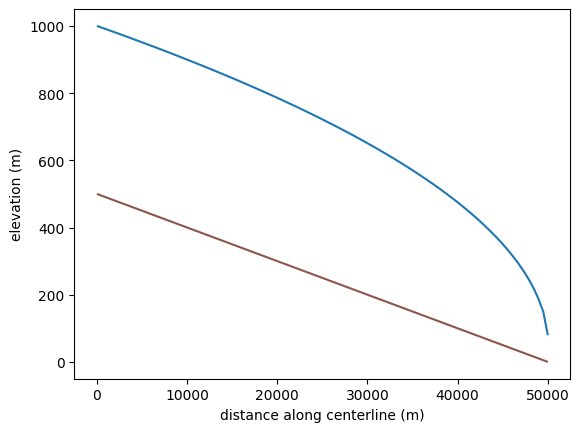

In [11]:
fig, axes = plt.subplots()
axes.set_xlabel("distance along centerline (m)")
axes.set_ylabel("elevation (m)")
firedrake.plot(
    icepack.depth_average(b), edgecolor="tab:brown", axes=axes
)
z_b = firedrake.Function(Q).interpolate(s - h)
firedrake.plot(
    extract_surface(s), edgecolor="tab:blue", axes=axes
);

In [12]:
z = firedrake.Function(Z)
z.sub(0).assign(u0)

u, Mx, Mz, τ = firedrake.split(z)
fields = {
    "velocity": u,
    "membrane_stress_x": Mx,
    "membrane_stress_z": Mz,
    "basal_stress": τ,
    "thickness": h,
    "surface": s,
    "outflow_ids": 2,
}
h_min = firedrake.Constant(10.0)
rfields = {
    "velocity": u,
    "membrane_stress_x": Mx,
    "membrane_stress_z": Mz,
    "basal_stress": τ,
    "thickness": max_value(h_min, h),
    "surface": s,
    "outflow_ids": 2,
}
rheology = {
    "flow_law_exponent": n,
    "flow_law_coefficient": ε_c / τ_c**n,
    "sliding_exponent": m,
    "sliding_coefficient": K / τ_c**m,
}
linear_rheology = {
    "flow_law_exponent": 1,
    "flow_law_coefficient": ε_c / τ_c,
    "sliding_exponent": 1,
    "sliding_coefficient": K / τ_c,
}

dual_model = hybrid.HybridModel()
L_1 = dual_model.action(**rfields, **linear_rheology)
F_1 = firedrake.derivative(L_1, z)
J_1 = firedrake.derivative(F_1, z)

L = dual_model.action(**fields, **rheology)
F = firedrake.derivative(L, z)

L_r = dual_model.action(**rfields, **rheology)
F_r = firedrake.derivative(L_r, z)
J_r = firedrake.derivative(F_r, z)
α = firedrake.Constant(0.01)
J = J_r + α * J_1

In [13]:
inflow_ids = [1]
bc_in = firedrake.DirichletBC(Z.sub(0), u0, inflow_ids)
bcs = [bc_in]

qdegree = int(max(glen_flow_law, weertman_sliding_law)) + 4
problem_params = {
    "form_compiler_parameters": {"quadrature_degree": qdegree},
    "bcs": bcs,
}
solver_params = {
    "solver_parameters": {
        #"snes_linesearch_monitor": None,
        #"snes_converged_reason": None,
        #"ksp_monitor": None,
        #"ksp_view": None,
        "snes_stol": 0.0,
        "snes_rtol": 0.0,
        "snes_atol": 1.0e-8,
        "snes_max_it": 2500,
        "snes_divergence_tolerance": -1,
        "snes_type": "newtonls",
        "snes_linesearch_type": "nleqerr",
        "ksp_type": "gmres",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "umfpack",
    },
}
# solver_params["solver_parameters"]["snes_monitor"] = None
# solver_params["solver_parameters"]["ksp_monitor"] = None
# firedrake.solve(F_1 == 0, z, **problem_params, **solver_params)

u_problem = firedrake.NonlinearVariationalProblem(F, z, J=J, **problem_params)
u_solver = firedrake.NonlinearVariationalSolver(u_problem, **solver_params)

u_solver.solve()
α.assign(0.0)

Constant([0.], name='constant_125', count=125)

## Primal velocity solve for comparison

In [14]:
model = icepack.models.HybridModel(friction=icepack.models.hybrid.bed_friction)
opts = {"dirichlet_ids": [1],
        "snes_stol": 0.0,
        "snes_rtol": 0.0,
        "snes_atol": 1.0e-8,
        "snes_max_it": 2500,
        "snes_divergence_tolerance": -1,}
solver = icepack.solvers.FlowSolver(model, **opts)

u_primal_0 = solver.diagnostic_solve(
    velocity=firedrake.Function(V).interpolate(u).copy(deepcopy=True),
    thickness=h,
    surface=s0,
    fluidity=A,
    friction=C,
)

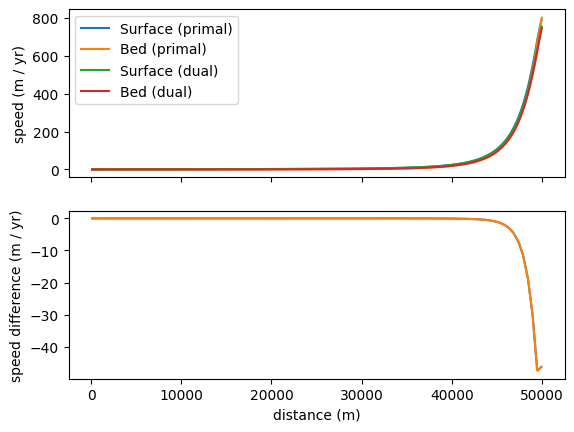

In [15]:
fig, axes = plt.subplots(2, 1, sharex=True)
axes[1].set_xlabel("distance (m)")
axes[1].set_ylabel("speed difference (m / yr)")
axes[0].set_ylabel("speed (m / yr)")
firedrake.plot(extract_surface(u_primal_0), axes=axes[0], label="Surface (primal)");
firedrake.plot(extract_bed(u_primal_0), axes=axes[0], label="Bed (primal)");
firedrake.plot(extract_surface(u), axes=axes[0], label="Surface (dual)");
firedrake.plot(extract_bed(u), axes=axes[0], label="Bed (dual)");
axes[0].legend(loc="upper left")

firedrake.plot(extract_bed(firedrake.Function(Q).project(u - u_primal_0)), axes=axes[1])
firedrake.plot(extract_surface(firedrake.Function(Q).project(u - u_primal_0)), axes=axes[1])

### Modeling

Do the prognostic problem with irksome timestepping.

In [16]:
from tqdm.notebook import trange

num_years = 100
timesteps_per_year = 4

dt = 1.0 / timesteps_per_year
num_timesteps = num_years * timesteps_per_year

a_0 = firedrake.Constant(1)
δa = firedrake.Constant(2.5)
a = firedrake.Function(Q).interpolate(a_0 - δa * x / Lx)

u_primal = u_primal_0.copy(deepcopy=True)

prognostic_problem = mass_balance(
    thickness=h,
    velocity=u,
    accumulation=a,
    thickness_inflow=h0,
    test_function=firedrake.TestFunction(Q),
)
t = firedrake.Constant(0.0)
method = irksome.BackwardEuler()
prognostic_params = {
    "solver_parameters": {
        "snes_type": "ksponly",
        "ksp_type": "gmres",
        "pc_type": "bjacobi",
    },
}
h_solver = irksome.TimeStepper(
    prognostic_problem, method, t, dt, h, **prognostic_params
)

for step in trange(num_timesteps):
    h_solver.advance()
    h.interpolate(firedrake.max_value(0.0, h))
    s.interpolate(icepack.compute_surface(thickness=h, bed=b))
    u_solver.solve()

  0%|          | 0/400 [00:00<?, ?it/s]

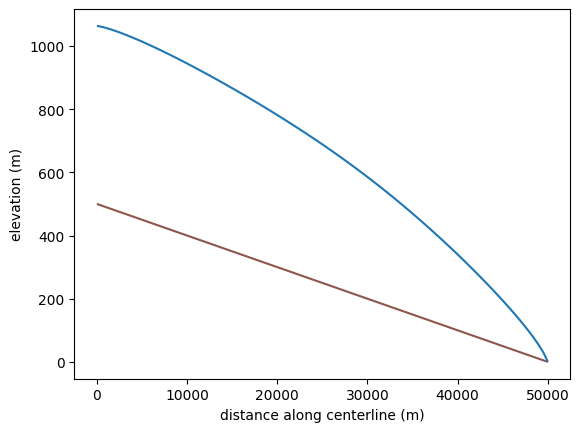

In [17]:
fig, axes = plt.subplots()
axes.set_xlabel("distance along centerline (m)")
axes.set_ylabel("elevation (m)")
firedrake.plot(
    icepack.depth_average(b), edgecolor="tab:brown", axes=axes
)
z_b = firedrake.Function(Q).interpolate(s - h)
firedrake.plot(
    extract_surface(s), edgecolor="tab:blue", axes=axes
);

## Comparison to primal
Calculate the velocity using the primal solver, compare.

In [18]:
u_primal = solver.diagnostic_solve(
    velocity=u,
    thickness=h,
    surface=s,
    fluidity=A,
    friction=C,
)

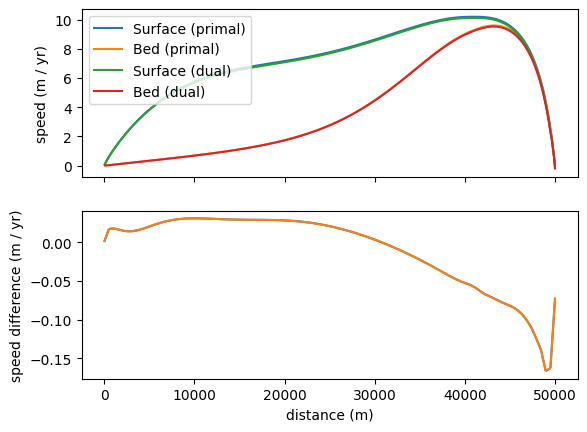

In [19]:
fig, axes = plt.subplots(2, 1, sharex=True)
axes[1].set_xlabel("distance (m)")
axes[1].set_ylabel("speed difference (m / yr)")
axes[0].set_ylabel("speed (m / yr)")
firedrake.plot(extract_surface(u_primal), axes=axes[0], label="Surface (primal)");
firedrake.plot(extract_bed(u_primal), axes=axes[0], label="Bed (primal)");
firedrake.plot(extract_surface(u), axes=axes[0], label="Surface (dual)");
firedrake.plot(extract_bed(u), axes=axes[0], label="Bed (dual)");

firedrake.plot(extract_bed(firedrake.Function(Q).project(u - u_primal)), axes=axes[1])
firedrake.plot(extract_surface(firedrake.Function(Q).project(u - u_primal)), axes=axes[1])
axes[0].legend(loc="upper left")